In [10]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [11]:
dataset_path = "data/glasses-noglasses"

train_path = os.path.join(dataset_path, "train")
val_path = os.path.join(dataset_path, "validate")

In [12]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(128,128),
    batch_size=16
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=(128,128),
    batch_size=16
)

Found 104 files belonging to 2 classes.
Found 40 files belonging to 2 classes.


In [13]:
print(train_ds.class_names)

['glasses', 'noglasses']


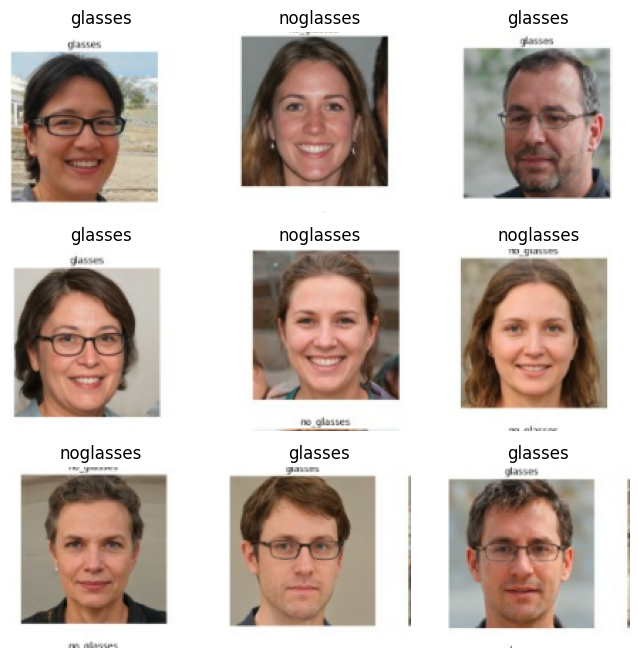

In [14]:
plt.figure(figsize=(8,8))

for images, labels in train_ds.take(1):

    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")

plt.show()

In [15]:
model = Sequential([
    
    Conv2D(32,(3,3),activation='relu',
           input_shape=(128,128,3)),
    
    MaxPooling2D(),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(),

    Flatten(),

    Dense(128,activation='relu'),

    Dropout(0.4),

    Dense(1,activation='sigmoid')
])

In [16]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.4615 - loss: 266.7624 - val_accuracy: 0.5000 - val_loss: 11.7934
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.4712 - loss: 7.7176 - val_accuracy: 0.5250 - val_loss: 0.7807
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6635 - loss: 0.6881 - val_accuracy: 0.5000 - val_loss: 0.7649
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7404 - loss: 0.4686 - val_accuracy: 0.5750 - val_loss: 0.9597
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8654 - loss: 0.2871 - val_accuracy: 0.5750 - val_loss: 1.7640
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9519 - loss: 0.1432 - val_accuracy: 0.6000 - val_loss: 1.7311
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9327 - loss: 0.2354 - val_accuracy: 0.5500 - val_loss: 2.2786
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9615 - loss: 0.1455 - val_accuracy: 0.6250 - val_loss: 2.01

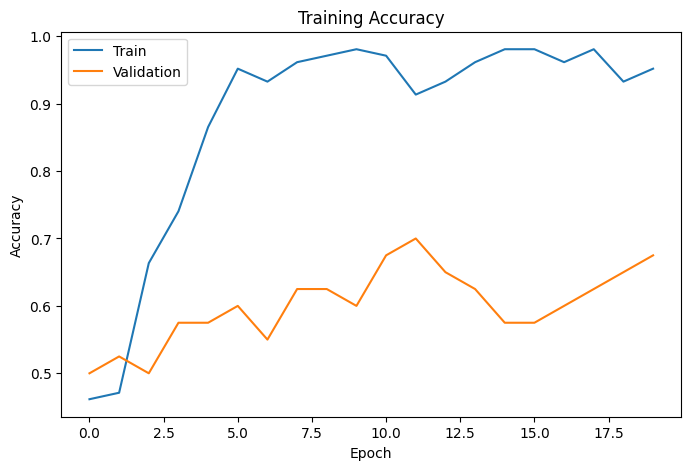

In [18]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

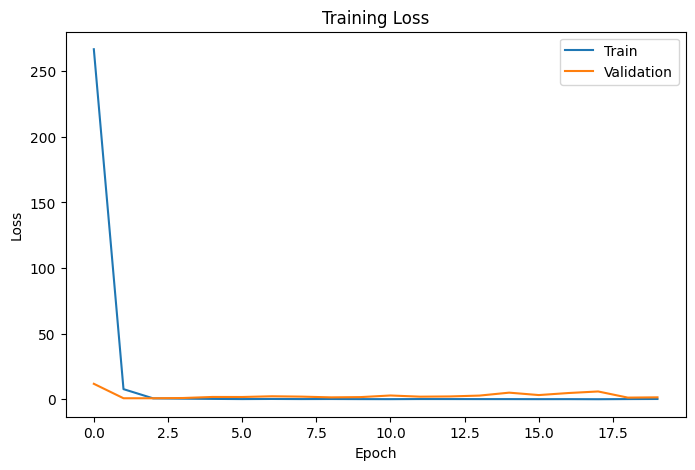

In [19]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

In [20]:
model.save("glasses_detector.keras")

print("Model Saved")

Model Saved
